# CausalML Meta-Learners on Uber Marketplace Environment

This notebook mirrors the workflow in the existing causal notebook, but replaces the custom learner with **causalml** meta-learners:

- T-Learner
- X-Learner
- R-Learner

We solve the same environment and run the same validation stack:

1. Confounding diagnostic on biased logs (Naive ATE vs True ATE)
2. Train each learner
3. Randomized holdout generation
4. Decile validation
5. Qini curve and normalized Qini comparison

Like the attached notebook, we evaluate the policy question: **20% discount vs 0% discount**.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import auc
from sklearn.base import clone
from xgboost import XGBRegressor

try:
    from causalml.inference.meta import BaseTRegressor, BaseXRegressor, BaseRRegressor
except ImportError:
    # If causalml is not installed in this kernel, install and re-import.
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "causalml"])
    from causalml.inference.meta import BaseTRegressor, BaseXRegressor, BaseRRegressor

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'caudyn').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from caudyn.environment import UberMarketplaceEnvironment

np.random.seed(42)
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

/home/hieule/research/uber-surge/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Utility Functions (Clean, Tutorial-Style)

Following the meta-learner tutorial style, we keep reusable logic in helper functions and keep main experiment cells short and readable.

These utilities cover:

- oracle counterfactual metrics from the environment
- data preparation for meta-learners
- model fitting and prediction
- decile validation
- Qini computation and plotting

In [2]:
TREATMENT_VALUE = 2
CONTROL_VALUE = 0
TREATMENT_LABEL = 'treat_20'
CONTROL_LABEL = 'control'

MODEL_KEY = {
    'T-Learner': 't',
    'X-Learner': 'x',
    'R-Learner': 'r',
}


def context_from_row(row):
    return {
        'recency': row['recency'],
        'frequency': row['frequency'],
        'weather_active': row['weather_active'],
        'surge_multiplier': row['surge_multiplier'],
    }


def add_oracle_counterfactuals(df, env, treat_value=TREATMENT_VALUE, control_value=CONTROL_VALUE):
    out = df.copy()
    out['true_conversion_20pct'] = out.apply(
        lambda r: env._calculate_true_conversion(context_from_row(r), treat_value), axis=1
    )
    out['true_conversion_0pct'] = out.apply(
        lambda r: env._calculate_true_conversion(context_from_row(r), control_value), axis=1
    )
    out['true_cate_20pct'] = out['true_conversion_20pct'] - out['true_conversion_0pct']
    return out


def summarize_naive_vs_true(df, treat_value=TREATMENT_VALUE, control_value=CONTROL_VALUE):
    naive_conv_20 = df.loc[df['treatment'] == treat_value, 'converted'].mean()
    naive_conv_0 = df.loc[df['treatment'] == control_value, 'converted'].mean()
    naive_ate = naive_conv_20 - naive_conv_0

    true_conv_20 = df['true_conversion_20pct'].mean()
    true_conv_0 = df['true_conversion_0pct'].mean()
    true_ate = df['true_cate_20pct'].mean()

    summary = pd.DataFrame({
        'Metric': [
            'Naive conversion @ 20%',
            'Naive conversion @ 0%',
            'Naive ATE (20% - 0%)',
            'True conversion @ 20%',
            'True conversion @ 0%',
            'True ATE (physics oracle)',
            'Bias (Naive - True)',
        ],
        'Value': [
            naive_conv_20,
            naive_conv_0,
            naive_ate,
            true_conv_20,
            true_conv_0,
            true_ate,
            naive_ate - true_ate,
        ],
    })

    metrics = {
        'naive_ate': naive_ate,
        'true_ate': true_ate,
    }
    return summary, metrics


def prepare_binary_meta_dataset(
    df,
    features,
    treat_value=TREATMENT_VALUE,
    control_value=CONTROL_VALUE,
):
    out = df[df['treatment'].isin([control_value, treat_value])].copy()
    out['treatment_label'] = np.where(out['treatment'] == treat_value, TREATMENT_LABEL, CONTROL_LABEL)

    X = out[features].to_numpy()
    y = out['converted'].astype(float).to_numpy()
    t = out['treatment_label'].to_numpy()
    return out, X, y, t


def build_base_learner(random_state=42):
    return XGBRegressor(
        n_estimators=300,
        max_depth=5,
        # learning_rate=0.05,
        # subsample=0.8,
        # colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=random_state,
    )


def build_treatment_learner(random_state=42):
    return XGBRegressor(
        n_estimators=300,
        max_depth=3,
        objective='reg:squarederror',
        random_state=random_state,
    )


def initialize_meta_learners(base_learner, treatment_learner):
    return {
        'T-Learner': BaseTRegressor(
            control_learner=clone(base_learner),
            treatment_learner=clone(treatment_learner),
            control_name=CONTROL_LABEL,
        ),
        'X-Learner': BaseXRegressor(
            control_outcome_learner=clone(base_learner),
            treatment_outcome_learner=clone(treatment_learner),
            control_effect_learner=clone(base_learner),
            treatment_effect_learner=clone(treatment_learner),
            control_name=CONTROL_LABEL,
        ),
        'R-Learner': BaseRRegressor(
            outcome_learner=clone(base_learner),
            effect_learner=clone(treatment_learner),
            control_name=CONTROL_LABEL,
        ),
    }


def flatten_te(te):
    arr = np.asarray(te)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2 and arr.shape[1] == 1:
        return arr[:, 0]
    return arr.mean(axis=1)


def fit_meta_learners(learners, X, t, y):
    for _, learner in learners.items():
        learner.fit(X=X, treatment=t, y=y)
    return learners


def add_meta_predictions(df, learners, X, model_key=MODEL_KEY):
    out = df.copy()
    for model_name, learner in learners.items():
        key = model_key[model_name]
        out[f'pred_cate_{key}'] = flatten_te(learner.predict(X))
    return out


def summarize_model_predictions(df, model_key=MODEL_KEY, true_col='true_cate_20pct', label='dataset'):
    rows = []
    for model_name, key in model_key.items():
        rows.append({
            'Model': model_name,
            f'Mean Predicted CATE ({label})': df[f'pred_cate_{key}'].mean(),
            f'Mean True CATE ({label})': df[true_col].mean(),
        })
    return pd.DataFrame(rows)


def generate_randomized_holdout(
    n_rows=20_000,
    seed=999,
    treatments=(CONTROL_VALUE, TREATMENT_VALUE),
):
    env = UberMarketplaceEnvironment(seed=seed)
    rng = np.random.default_rng(seed)

    rows = []
    for _ in range(n_rows):
        context = env.reset()
        action = int(rng.choice(treatments))
        _, reward, true_prob = env.step(action)

        row = context.copy()
        row['treatment'] = action
        row['treatment_label'] = TREATMENT_LABEL if action == TREATMENT_VALUE else CONTROL_LABEL
        row['discount_value'] = env.discount_levels[action]
        row['converted'] = reward
        row['true_prob_observed'] = true_prob
        rows.append(row)

    return env, pd.DataFrame(rows)


def decile_validation_table(df, score_col):
    ranked = df.sort_values(score_col, ascending=False).reset_index(drop=True).copy()
    ranked['decile'] = pd.qcut(ranked.index, q=10, labels=np.arange(1, 11))

    rows = []
    for d in range(1, 11):
        sub = ranked[ranked['decile'] == d]
        conv_treated = sub.loc[sub['treatment'] == TREATMENT_VALUE, 'converted'].mean()
        conv_control = sub.loc[sub['treatment'] == CONTROL_VALUE, 'converted'].mean()
        rows.append({
            'Decile': d,
            'Predicted_Lift': sub[score_col].mean(),
            'Actual_Lift': conv_treated - conv_control,
            'n': len(sub),
        })

    return ranked, pd.DataFrame(rows)


def build_all_deciles(df, model_score_cols):
    ranked_frames = {}
    decile_tables = {}

    for model_name, score_col in model_score_cols.items():
        ranked_df, decile_df = decile_validation_table(df, score_col)
        ranked_frames[model_name] = ranked_df
        decile_tables[model_name] = decile_df

    return ranked_frames, decile_tables


def plot_decile_comparison(decile_tables):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

    for ax, (model_name, decile_df) in zip(axes, decile_tables.items()):
        x = np.arange(len(decile_df))
        width = 0.38
        ax.bar(x - width / 2, decile_df['Predicted_Lift'], width, label='Predicted', color='#4C78A8')
        ax.bar(x + width / 2, decile_df['Actual_Lift'], width, label='Actual', color='#F58518')
        ax.set_title(model_name)
        ax.set_xlabel('Decile (1 = highest predicted uplift)')
        ax.set_xticks(x)
        ax.set_xticklabels(decile_df['Decile'])
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    axes[0].set_ylabel('Lift')
    axes[0].legend(loc='best')
    fig.suptitle('Decile Validation: Predicted vs Actual Lift (RCT)', y=1.05)
    plt.tight_layout()
    plt.show()


def summarize_decile_ranking(df, decile_tables, model_score_cols, true_col='true_cate_20pct'):
    rows = []
    for model_name, score_col in model_score_cols.items():
        decile_df = decile_tables[model_name]
        top_actual = decile_df.loc[decile_df['Decile'] == 1, 'Actual_Lift'].iloc[0]
        bottom_actual = decile_df.loc[decile_df['Decile'] == 10, 'Actual_Lift'].iloc[0]
        spread = top_actual - bottom_actual
        spearman_vs_true = pd.Series(df[score_col]).corr(df[true_col], method='spearman')

        rows.append({
            'Model': model_name,
            'Top Decile Actual Lift': top_actual,
            'Bottom Decile Actual Lift': bottom_actual,
            'Decile Lift Spread (Top-Bottom)': spread,
            'Spearman Corr(pred, true CATE)': spearman_vs_true,
        })

    return pd.DataFrame(rows).sort_values('Decile Lift Spread (Top-Bottom)', ascending=False)


def calculate_qini_curve(df):
    w = (df['treatment'] == TREATMENT_VALUE).astype(int).to_numpy()
    y = df['converted'].to_numpy()

    cum_treated = np.cumsum(w)
    cum_control = np.cumsum(1 - w)
    cum_y_treated = np.cumsum(y * w)
    cum_y_control = np.cumsum(y * (1 - w))

    eps = 1e-10
    incremental_gain = cum_y_treated - cum_y_control * (cum_treated / (cum_control + eps))
    return np.insert(incremental_gain, 0, 0.0)


def qini_analysis(df, model_score_cols, true_col='true_cate_20pct'):
    x_axis = np.arange(len(df) + 1) / len(df)

    qini_endpoint = calculate_qini_curve(df)[-1]
    qini_random = x_axis * qini_endpoint
    area_random = auc(x_axis, qini_random)

    df_perfect = df.sort_values(true_col, ascending=False).reset_index(drop=True)
    qini_perfect = calculate_qini_curve(df_perfect)
    area_perfect = auc(x_axis, qini_perfect)

    qini_curves = {}
    qini_rows = []

    for model_name, score_col in model_score_cols.items():
        ranked = df.sort_values(score_col, ascending=False).reset_index(drop=True)
        qini_curve = calculate_qini_curve(ranked)
        qini_curves[model_name] = qini_curve

        area_model = auc(x_axis, qini_curve)
        denom = area_perfect - area_random
        qini_norm = np.nan if abs(denom) < 1e-12 else (area_model - area_random) / denom

        qini_rows.append({
            'Model': model_name,
            'AUC_Model': area_model,
            'AUC_Random': area_random,
            'AUC_Perfect': area_perfect,
            'Qini_Normalized': qini_norm,
        })

    qini_results = pd.DataFrame(qini_rows).sort_values('Qini_Normalized', ascending=False).reset_index(drop=True)
    return x_axis, qini_random, qini_perfect, qini_curves, qini_results


def plot_qini_comparison(x_axis, qini_random, qini_perfect, qini_curves, best_model):
    _, ax = plt.subplots(figsize=(12, 6))
    ax.plot(x_axis, qini_random, label='Random Baseline', color='#9E9E9E', linestyle='--', linewidth=2)
    ax.plot(x_axis, qini_perfect, label='Perfect (Oracle)', color='#54A24B', linewidth=2.5)

    color_map = {'T-Learner': '#4C78A8', 'X-Learner': '#E45756', 'R-Learner': '#72B7B2'}
    for model_name, curve in qini_curves.items():
        ax.plot(x_axis, curve, label=model_name, color=color_map[model_name], linewidth=2.2)

    ax.fill_between(
        x_axis,
        qini_random,
        qini_curves[best_model],
        where=(qini_curves[best_model] >= qini_random),
        color=color_map[best_model],
        alpha=0.15,
        interpolate=True,
    )

    ax.set_title('Qini Curves: T vs X vs R Learners')
    ax.set_xlabel('Fraction of users targeted')
    ax.set_ylabel('Cumulative incremental conversions')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

In [3]:
# Interval-aware helpers based on causalml tutorial patterns.
# - CATE point estimates: learner.predict(...)
# - ATE estimate/lower/upper: learner.estimate_ate(...)

def _treatment_index(learner, treatment_label=TREATMENT_LABEL):
    classes = getattr(learner, '_classes', {})
    if isinstance(classes, dict) and treatment_label in classes:
        return int(classes[treatment_label])
    return 0


def _vector_for_treatment(values, learner, treatment_label=TREATMENT_LABEL):
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 0:
        return np.array([float(arr)], dtype=float)
    if arr.ndim == 1:
        return arr.astype(float)
    if arr.ndim == 2:
        if arr.shape[1] == 1:
            return arr[:, 0].astype(float)
        idx = _treatment_index(learner, treatment_label=treatment_label)
        return arr[:, idx].astype(float)
    return arr.reshape(-1).astype(float)


def _scalar_for_treatment(values, learner, treatment_label=TREATMENT_LABEL):
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 0:
        return float(arr)
    if arr.ndim == 1:
        if arr.size == 1:
            return float(arr[0])
        idx = _treatment_index(learner, treatment_label=treatment_label)
        return float(arr[idx])
    if arr.ndim == 2:
        if arr.shape[0] == 1:
            arr = arr[0]
        elif arr.shape[1] == 1:
            arr = arr[:, 0]
        else:
            idx = _treatment_index(learner, treatment_label=treatment_label)
            return float(arr[0, idx])
        return _scalar_for_treatment(arr, learner, treatment_label=treatment_label)
    return float(arr.reshape(-1)[0])


def _estimate_ate_interval(
    learner,
    X,
    treatment,
    y,
    treatment_label=TREATMENT_LABEL,
    bootstrap_ci=False,
    n_bootstraps=100,
    bootstrap_size=5000,
):
    kwargs = {
        'X': X,
        'treatment': treatment,
        'y': y,
        'bootstrap_ci': bootstrap_ci,
    }
    if bootstrap_ci:
        kwargs['n_bootstraps'] = n_bootstraps
        kwargs['bootstrap_size'] = min(int(bootstrap_size), len(y))

    # Preferred: tutorial-style interval from an already-fitted learner.
    # Fallback: fit-on-dataset mode when pretrain=True is incompatible (e.g., X-learner propensity shape mismatch).
    try:
        ate, ate_lb, ate_ub = learner.estimate_ate(pretrain=True, **kwargs)
    except Exception:
        ate, ate_lb, ate_ub = learner.estimate_ate(pretrain=False, **kwargs)

    return (
        _scalar_for_treatment(ate, learner, treatment_label=treatment_label),
        _scalar_for_treatment(ate_lb, learner, treatment_label=treatment_label),
        _scalar_for_treatment(ate_ub, learner, treatment_label=treatment_label),
    )


def add_meta_predictions(df, learners, X, model_key=MODEL_KEY, treatment_label=TREATMENT_LABEL):
    out = df.copy()
    for model_name, learner in learners.items():
        key = model_key[model_name]
        estimate = _vector_for_treatment(learner.predict(X), learner, treatment_label=treatment_label)

        # Keep estimate alias for downstream ranking code.
        out[f'pred_cate_{key}'] = estimate

        # Explicit naming for report tables.
        out[f'pred_cate_estimate_{key}'] = estimate
    return out


def summarize_model_predictions(
    df,
    learners,
    X,
    treatment,
    y,
    model_key=MODEL_KEY,
    true_col='true_cate_20pct',
    label='dataset',
    treatment_label=TREATMENT_LABEL,
    bootstrap_ci=False,
    n_bootstraps=100,
    bootstrap_size=5000,
):
    rows = []
    for model_name in model_key:
        learner = learners[model_name]
        est, lb, ub = _estimate_ate_interval(
            learner=learner,
            X=X,
            treatment=treatment,
            y=y,
            treatment_label=treatment_label,
            bootstrap_ci=bootstrap_ci,
            n_bootstraps=n_bootstraps,
            bootstrap_size=bootstrap_size,
        )

        rows.append({
            'Model': model_name,
            f'Mean CATE Estimate ({label})': est,
            f'Mean CATE Lower Bound ({label})': lb,
            f'Mean CATE Upper Bound ({label})': ub,
            f'Mean True CATE ({label})': df[true_col].mean(),
        })
    return pd.DataFrame(rows)

## Step 1: Environment and the Confounding Illusion

We first generate **biased observational logs** from the legacy policy and compare:

- Naive conversion and Naive ATE from observational averages
- True conversion and True ATE from the hidden simulator physics

This reproduces the confounding demonstration from the attached notebook.

In [4]:
env = UberMarketplaceEnvironment(seed=42)
df_hist = env.generate_biased_historical_data(num_samples=200_000)

features = ['recency', 'frequency', 'weather_active', 'surge_multiplier']

df_hist = add_oracle_counterfactuals(df_hist, env)
summary_step1, step1_metrics = summarize_naive_vs_true(df_hist)

print(f"Rows generated: {len(df_hist):,}")
display(summary_step1.style.format({'Value': '{:.2%}'}))

policy_diagnosis = df_hist.groupby('treatment')['frequency'].mean().rename('avg_frequency').to_frame()
print('Average monthly frequency by treatment arm (legacy policy):')
display(policy_diagnosis)

Rows generated: 200,000


,Metric,Value
0,Naive conversion @ 20%,59.39%
1,Naive conversion @ 0%,12.93%
2,Naive ATE (20% - 0%),46.46%
3,True conversion @ 20%,41.22%
4,True conversion @ 0%,35.46%
5,True ATE (physics oracle),5.76%
6,Bias (Naive - True),40.70%


Average monthly frequency by treatment arm (legacy policy):


,avg_frequency
treatment,
0,4.639606
1,10.481108
2,16.361204


### Why We Reframe to Binary Treatment for CausalML Meta-Learners

The legacy logs contain three actions (0%, 10%, 20%).

To match the attached notebook's business question and causalml meta-learner assumptions, we train on **binary treatment**:

- `control`: 0% discount
- `treat_20`: 20% discount

Rows with 10% discount are excluded for this comparison study.

## Step 2: Train T-, X-, and R-Learners from causalml

Following the causalml meta-learner tutorial pattern, this step is split into:

1. Prepare treatment, outcome, and feature matrices
2. Initialize learners with dedicated control and treatment regressors
3. Fit each learner
4. Estimate CATE on train and holdout

In [5]:
df_train_bin, X_train, y_train, t_train = prepare_binary_meta_dataset(df_hist, features)

print('Training rows (0% vs 20% only): {:,}'.format(len(df_train_bin)))
print('Dropped 10% rows: {:,}'.format(len(df_hist) - len(df_train_bin)))

base_xgb = build_base_learner(random_state=42)
treatment_xgb = build_treatment_learner(random_state=42)
learners = initialize_meta_learners(base_xgb, treatment_xgb)
learners = fit_meta_learners(learners, X_train, t_train, y_train)

df_train_bin = add_meta_predictions(df_train_bin, learners, X_train)
train_summary = summarize_model_predictions(
    df=df_train_bin,
    learners=learners,
    X=X_train,
    treatment=df_train_bin['treatment_label'].to_numpy(),
    y=df_train_bin['converted'].astype(float).to_numpy(),
    label='train',
    bootstrap_ci=False,
)

display(train_summary.style.format({
    'Mean CATE Estimate (train)': '{:.2%}',
    'Mean CATE Lower Bound (train)': '{:.2%}',
    'Mean CATE Upper Bound (train)': '{:.2%}',
    'Mean True CATE (train)': '{:.2%}',
}))

Training rows (0% vs 20% only): 122,323
Dropped 10% rows: 77,677


,Model,Mean CATE Estimate (train),Mean CATE Lower Bound (train),Mean CATE Upper Bound (train),Mean True CATE (train)
0,T-Learner,7.17%,6.73%,7.61%,6.63%
1,X-Learner,6.91%,6.47%,7.35%,6.63%
2,R-Learner,7.12%,7.12%,7.12%,6.63%


## Step 3: Randomized Holdout (RCT Sandbox)

As in the attached notebook, we validate on a fresh randomized dataset where treatment assignment is independent of user profile.

This gives a clean offline testbed for uplift ranking quality.

In [6]:
env_rct, df_rct = generate_randomized_holdout(n_rows=20_000, seed=999)
df_rct = add_oracle_counterfactuals(df_rct, env_rct)

X_rct = df_rct[features].to_numpy()
df_rct = add_meta_predictions(df_rct, learners, X_rct)

holdout_summary = summarize_model_predictions(
    df=df_rct,
    learners=learners,
    X=X_rct,
    treatment=df_rct['treatment_label'].to_numpy(),
    y=df_rct['converted'].astype(float).to_numpy(),
    label='RCT',
    bootstrap_ci=False,
)

print(f"RCT rows generated: {len(df_rct):,}")
print('Treatment share (near 50/50 expected):')
display(df_rct['treatment'].value_counts(normalize=True).sort_index().rename('share'))
display(holdout_summary.style.format({
    'Mean CATE Estimate (RCT)': '{:.2%}',
    'Mean CATE Lower Bound (RCT)': '{:.2%}',
    'Mean CATE Upper Bound (RCT)': '{:.2%}',
    'Mean True CATE (RCT)': '{:.2%}',
}))

RCT rows generated: 20,000
Treatment share (near 50/50 expected):


treatment
0    0.4994
2    0.5006
Name: share, dtype: float64

,Model,Mean CATE Estimate (RCT),Mean CATE Lower Bound (RCT),Mean CATE Upper Bound (RCT),Mean True CATE (RCT)
0,T-Learner,6.89%,5.61%,8.17%,5.68%
1,X-Learner,7.07%,5.98%,8.16%,5.68%
2,R-Learner,6.78%,6.77%,6.78%,5.68%


## Step 4: Validation Part 1 - Decile Binning

For each learner:

1. Sort users by predicted uplift (high to low)
2. Split into 10 deciles
3. Compute actual lift in each decile (treated conversion - control conversion)

Then compare predicted vs actual lift patterns across T, X, and R learners.

=== T-Learner Deciles ===


,Decile,Predicted_Lift,Actual_Lift,n
0,1,36.21%,11.14%,2000
1,2,22.73%,10.77%,2000
2,3,17.89%,13.23%,2000
3,4,13.86%,8.57%,2000
4,5,10.21%,8.50%,2000
5,6,6.54%,5.21%,2000
6,7,2.27%,4.23%,2000
7,8,-3.35%,1.26%,2000
8,9,-10.92%,0.61%,2000
9,10,-26.55%,2.56%,2000


=== X-Learner Deciles ===


,Decile,Predicted_Lift,Actual_Lift,n
0,1,33.39%,12.25%,2000
1,2,21.30%,10.71%,2000
2,3,16.14%,8.89%,2000
3,4,12.29%,10.93%,2000
4,5,9.00%,6.83%,2000
5,6,5.57%,8.31%,2000
6,7,1.94%,2.03%,2000
7,8,-2.40%,3.50%,2000
8,9,-8.58%,1.41%,2000
9,10,-22.34%,0.99%,2000


=== R-Learner Deciles ===


,Decile,Predicted_Lift,Actual_Lift,n
0,1,32.31%,13.90%,2000
1,2,19.36%,11.47%,2000
2,3,14.26%,12.68%,2000
3,4,10.57%,5.21%,2000
4,5,7.43%,8.36%,2000
5,6,4.40%,8.20%,2000
6,7,1.52%,2.24%,2000
7,8,-1.54%,-0.64%,2000
8,9,-5.53%,2.80%,2000
9,10,-15.01%,0.67%,2000


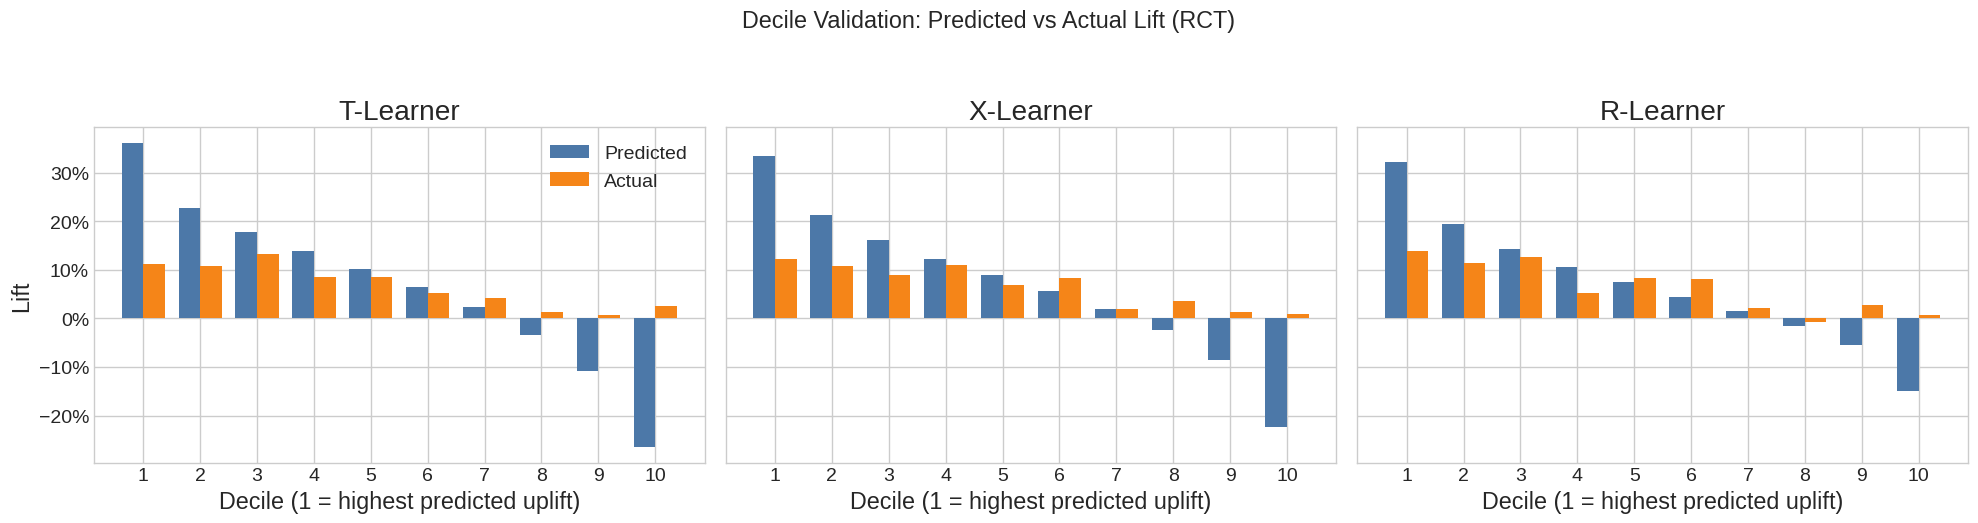

In [7]:
model_score_cols = {
    model_name: f"pred_cate_{key}"
    for model_name, key in MODEL_KEY.items()
}

ranked_frames, decile_tables = build_all_deciles(df_rct, model_score_cols)

for model_name, decile_df in decile_tables.items():
    print(f"=== {model_name} Deciles ===")
    display(decile_df.style.format({
        'Predicted_Lift': '{:.2%}',
        'Actual_Lift': '{:.2%}',
    }))

plot_decile_comparison(decile_tables)

In [8]:
ranking_df = summarize_decile_ranking(
    df=df_rct,
    decile_tables=decile_tables,
    model_score_cols=model_score_cols,
    true_col='true_cate_20pct',
)

display(ranking_df.style.format({
    'Top Decile Actual Lift': '{:.2%}',
    'Bottom Decile Actual Lift': '{:.2%}',
    'Decile Lift Spread (Top-Bottom)': '{:.2%}',
    'Spearman Corr(pred, true CATE)': '{:.3f}',
}))

,Model,Top Decile Actual Lift,Bottom Decile Actual Lift,Decile Lift Spread (Top-Bottom),"Spearman Corr(pred, true CATE)"
2,R-Learner,13.90%,0.67%,13.23%,0.545
1,X-Learner,12.25%,0.99%,11.26%,0.491
0,T-Learner,11.14%,2.56%,8.58%,0.439


## Step 5: Validation Part 2 - Qini Curves and Normalized Qini

We compute Qini for each learner and compare against:

- Random baseline
- Oracle perfect ranking (sorted by true CATE)

Normalized Qini score:

$$
\text{Qini}_{\text{norm}} = \frac{A_{\text{model}} - A_{\text{random}}}{A_{\text{perfect}} - A_{\text{random}}}
$$

,Model,AUC_Model,AUC_Random,AUC_Perfect,Qini_Normalized
0,R-Learner,458.79,318.71,531.23,0.659
1,T-Learner,445.53,318.71,531.23,0.597
2,X-Learner,443.46,318.71,531.23,0.587


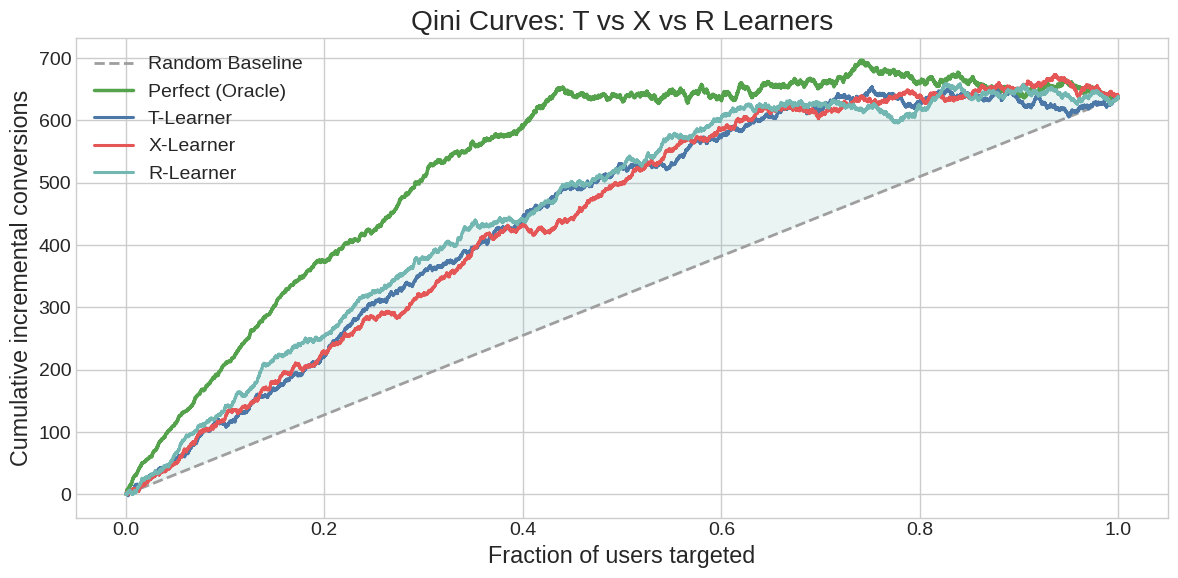

In [9]:
x_axis, qini_random, qini_perfect, qini_curves, qini_results = qini_analysis(
    df=df_rct,
    model_score_cols=model_score_cols,
    true_col='true_cate_20pct',
)

display(qini_results.style.format({
    'AUC_Model': '{:,.2f}',
    'AUC_Random': '{:,.2f}',
    'AUC_Perfect': '{:,.2f}',
    'Qini_Normalized': '{:.3f}',
}))

best_model = qini_results.loc[0, 'Model']
plot_qini_comparison(
    x_axis=x_axis,
    qini_random=qini_random,
    qini_perfect=qini_perfect,
    qini_curves=qini_curves,
    best_model=best_model,
)

In [10]:
final_comparison = ranking_df.merge(qini_results[['Model', 'Qini_Normalized']], on='Model', how='left')
final_comparison = final_comparison.sort_values('Qini_Normalized', ascending=False).reset_index(drop=True)

display(final_comparison.style.format({
    'Top Decile Actual Lift': '{:.2%}',
    'Bottom Decile Actual Lift': '{:.2%}',
    'Decile Lift Spread (Top-Bottom)': '{:.2%}',
    'Spearman Corr(pred, true CATE)': '{:.3f}',
    'Qini_Normalized': '{:.3f}',
}))

print('Best model by normalized Qini:', final_comparison.loc[0, 'Model'])

,Model,Top Decile Actual Lift,Bottom Decile Actual Lift,Decile Lift Spread (Top-Bottom),"Spearman Corr(pred, true CATE)",Qini_Normalized
0,R-Learner,13.90%,0.67%,13.23%,0.545,0.659
1,T-Learner,11.14%,2.56%,8.58%,0.439,0.597
2,X-Learner,12.25%,0.99%,11.26%,0.491,0.587


Best model by normalized Qini: R-Learner


## Key Takeaways

1. Naive observational estimates remain biased under policy-driven confounding.
2. causalml T/X/R learners can all recover uplift signal, but ranking quality differs.
3. Decile and Qini analyses provide complementary views of business targeting quality.
4. Use randomized holdout slices in production monitoring to detect ranking drift.

You can now swap base models, tune hyperparameters, or evaluate additional learners (S-learner, DR-learner) using the same validation scaffold.